## **Tipos de regresión**
* Lineal (simple y múltiple)
* Polinómica
* Logística

---

## **Regresión Polinómica**

* Utiliza polinomios de grado superior.

$$y = b_0 + b_1x + b_2x^2 + \dots + b_nx^n$$

Funciona mejor cuando la relación no es tan lineal.

## **Cálculos Matemáticos**

* Cálculo del coeficiente de intersección:$$b_0 = \bar{y} - b_1\bar{x} - b_2\bar{x}^2 - \dots - b_n\bar{x}^n$$

* Cálculo de los coeficientes de pendiente $b_i$ (**método MCO**), también de forma independiente:$$b_i = \frac{\sum_{j=1}^{m}(x_j - \bar{x})^i(y_j - \bar{y})}{\sum_{j=1}^{m}(x_j - \bar{x})^{2i}}$$

---

Usaremos un polinomio de grado 2: $y = b_0 + b_1x + b_2x^2$.

---

**1. Nivel Nativo (Álgebra Lineal)**

Para el nivel nativo, transformamos nuestros datos $x$ en una matriz que incluya $x^2$ y usamos la Ecuación Normal.

In [1]:
import numpy as np

# Datos: Horas de estudio
x = np.array([1, 2, 3, 4, 5])
y = np.array([45, 65, 80, 85, 88]) # Relación no lineal

# Crear matriz con [1, x, x^2]
X_poly = np.c_[np.ones(5), x, x**2]

# Entrenamiento (Ecuación Normal): beta = (X^T * X)^-1 * X^T * y
beta = np.linalg.inv(X_poly.T.dot(X_poly)).dot(X_poly.T).dot(y)

# Predicción para 6 horas
nuevo_x = 6
prediccion = beta[0] + beta[1]*nuevo_x + beta[2]*(nuevo_x**2)
print(f"Predicción Nativa (6h): {prediccion:.2f}")

Predicción Nativa (6h): 82.40


---
**2. TensorFlow (Nivel Bajo)**

Aquí definimos manualmente los tres coeficientes ($b_0, b_1, b_2$) y optimizamos la función cuadrática.

In [2]:
import tensorflow as tf

x_tensor = tf.constant([1., 2., 3., 4., 5.], dtype=tf.float32)
y_tensor = tf.constant([45., 65., 80., 85., 88.], dtype=tf.float32)

# Variables del polinomio: y = b2*x^2 + b1*x + b0
b2 = tf.Variable(0.0)
b1 = tf.Variable(0.0)
b0 = tf.Variable(0.0)

opt = tf.optimizers.Adam(learning_rate=0.1)

for _ in range(2000):
    with tf.GradientTape() as tape:
        y_pred = b2*(x_tensor**2) + b1*x_tensor + b0
        loss = tf.reduce_mean(tf.square(y_tensor - y_pred))
    grads = tape.gradient(loss, [b2, b1, b0])
    opt.apply_gradients(zip(grads, [b2, b1, b0]))

print(f"Predicción TF: {(b2*6**2 + b1*6 + b0).numpy():.2f}")

Predicción TF: 90.67


---
**3. Keras (Red Neuronal)**

En Keras, podemos pasar las características ya transformadas ($x$ y $x^2$) a una capa densa para simular el polinomio.

In [4]:
from tensorflow import keras
import numpy as np

x = np.array([1, 2, 3, 4, 5])
X_poly = np.column_stack((x, x**2)) # Generamos las potencias
y = np.array([45, 65, 80, 85, 88])

model = keras.Sequential([
    keras.layers.Dense(units=1, input_shape=[2]) # Entrada: x y x^2
])

model.compile(optimizer=keras.optimizers.Adam(0.1), loss='mse')
model.fit(X_poly, y, epochs=1000, verbose=0)

# Predicción para 6 horas
print(f"Predicción Keras (6h): {model.predict(np.array([[6, 36]]))[0][0]:.2f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicción Keras (6h): 92.01


---
**4. Scikit-Learn (Pipeline)**

Este es el estándar industrial. Utilizamos un `Pipeline` que primero transforma los datos a grado superior y luego aplica la regresión lineal.

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

x = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([45, 65, 80, 85, 88])

# Pipeline: Transforma a grado 2 y luego entrena
model = Pipeline([
    ('poly', PolynomialFeatures(degree=2)),
    ('linear', LinearRegression())
])

model.fit(x, y)

# Calcular nuevo valor
prediccion = model.predict([[6]])
print(f"Predicción Sklearn (6h): {prediccion[0]:.2f}")

Predicción Sklearn (6h): 82.40


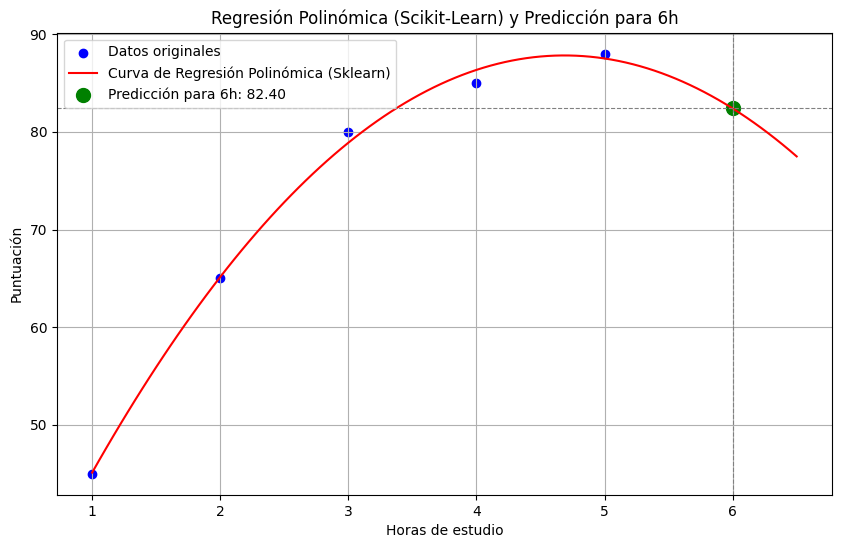

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Original data from cell IQZBj0kDDhW3
x_original = np.array([1, 2, 3, 4, 5])
y_original = np.array([45, 65, 80, 85, 88])

# Generate a smooth range of x values for plotting the curve
x_plot = np.linspace(min(x_original), 6.5, 100).reshape(-1, 1)
y_plot = model.predict(x_plot)

# Create the plot
plt.figure(figsize=(10, 6))
plt.scatter(x_original, y_original, color='blue', label='Datos originales')
plt.plot(x_plot, y_plot, color='red', label='Curva de Regresión Polinómica (Sklearn)')

# Highlight the prediction for 6 hours
plt.scatter(6, prediccion[0], color='green', marker='o', s=100, label=f'Predicción para 6h: {prediccion[0]:.2f}')
plt.axvline(x=6, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(y=prediccion[0], color='gray', linestyle='--', linewidth=0.8)

plt.title('Regresión Polinómica (Scikit-Learn) y Predicción para 6h')
plt.xlabel('Horas de estudio')
plt.ylabel('Puntuación')
plt.legend()
plt.grid(True)
plt.show()

**Diferencia clave:** Mientras que en la lineal buscamos una recta, en la polinómica el modelo calcula la "curvatura" óptima para pasar lo más cerca posible de los puntos.